# **Лабораторная работа №3: Понижение размерности**

##**1. Геометрия данных в пространстве признаков**

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
Размер датасета: 20640 строк, 10 столбцов
Число числовых признаков: 9


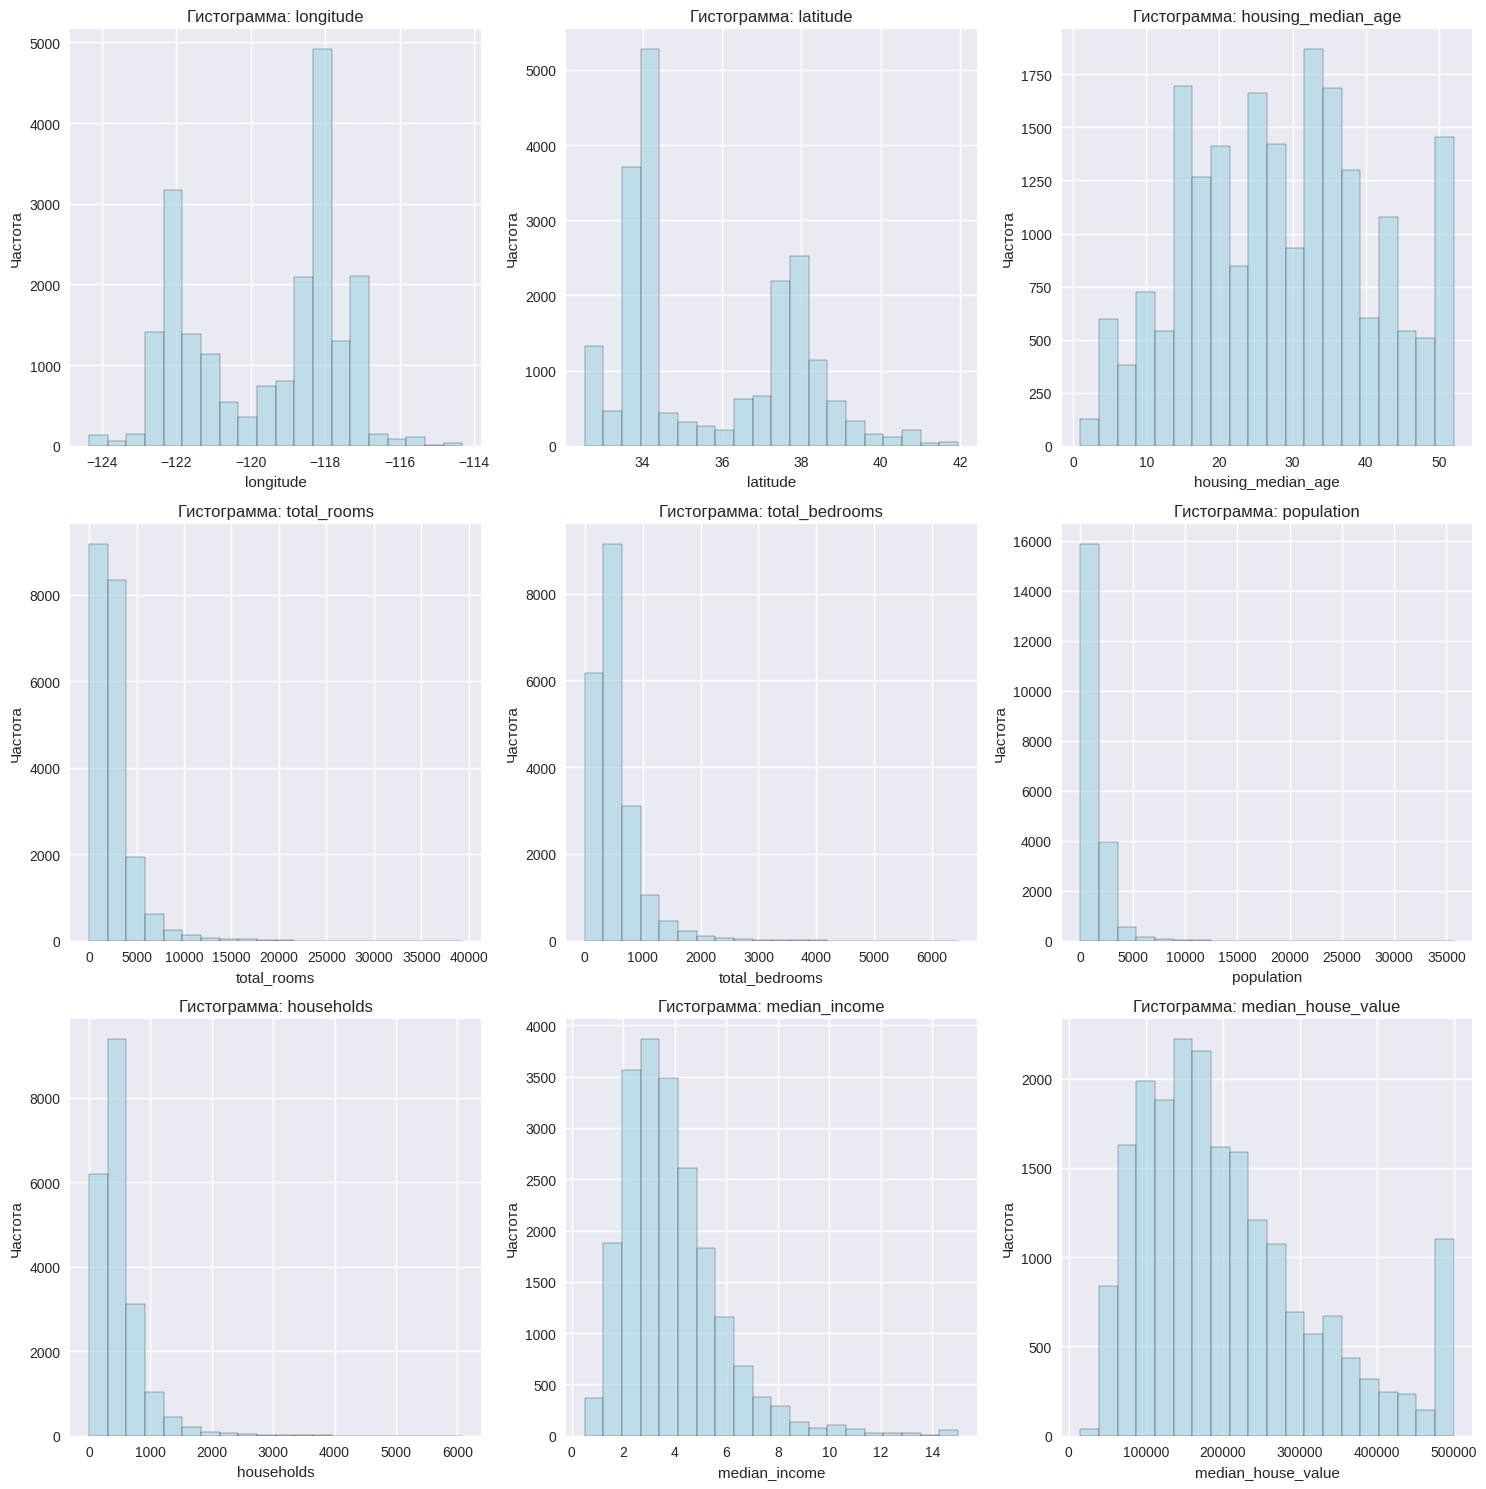

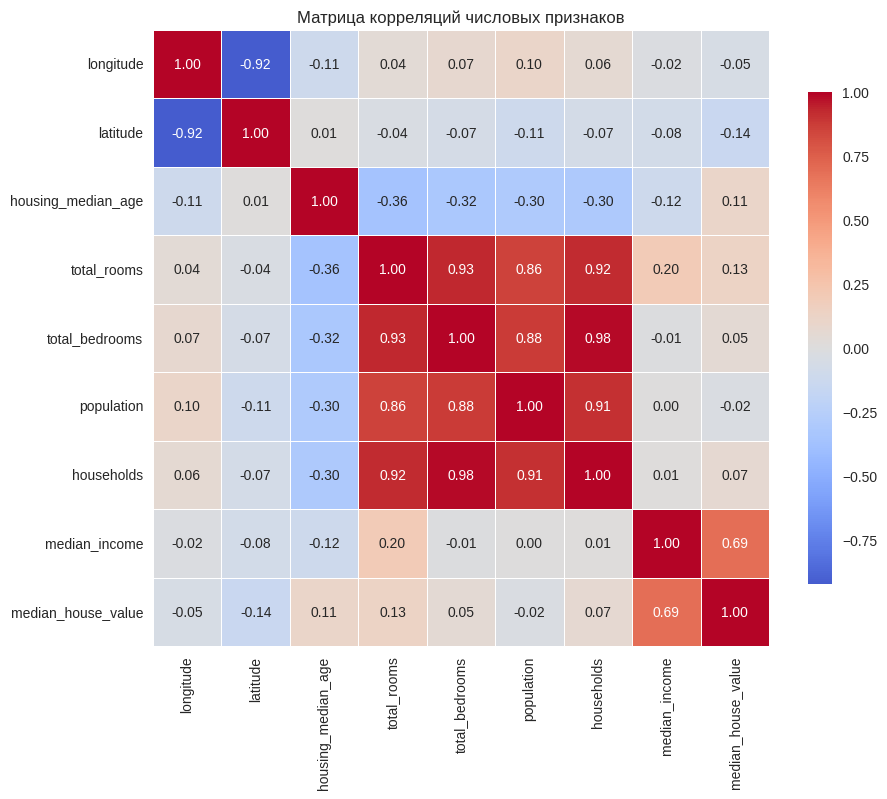


Анализ корреляции
Обнаружены сильно коррелированные пары признаков (|r| ≥ 0.8):
  longitude и latitude: r = -0.925
  total_rooms и total_bedrooms: r = 0.930
  total_rooms и population: r = 0.857
  total_rooms и households: r = 0.918
  total_bedrooms и population: r = 0.878
  total_bedrooms и households: r = 0.980
  population и households: r = 0.907

Вывод: Да, есть сильно коррелированные признаки. Это может означать, что часть информации дублируется.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('/content/data/housing.csv')
print(df.head())
num_rows, num_cols = df.shape
print(f'Размер датасета: {num_rows} строк, {num_cols} столбцов')

numeric_df = df.select_dtypes(include=[np.number])
print(f'Число числовых признаков: {numeric_df.shape[1]}')

#Гистограмма распределения для каждого числ признака
#Сетка графиков: количество строк зависит от числа признаков, 3 столбца
n_features = numeric_df.shape[1]
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Округление вверх

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Преобразуем массив осей в одномерный для удобства

# Перебираем числовые признаки и строим гистограммы
for idx, column in enumerate(numeric_df.columns):
    axes[idx].hist(numeric_df[column].dropna(), bins=20, alpha=0.7, edgecolor='black', color='lightblue')
    axes[idx].set_title(f'Гистограмма: {column}')
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel('Частота')

# Скрываем пустые графики, если их больше, чем нужно
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Матрица корреляций
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций числовых признаков')
plt.show()


# Поиск сильно коррелированных признаков (|r| > 0.8)
high_corr_pairs = []
threshold = 0.8
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) >= threshold:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            high_corr_pairs.append((feature1, feature2, corr_value))

print("\nАнализ корреляции")
if high_corr_pairs:
    print("Обнаружены сильно коррелированные пары признаков (|r| ≥ 0.8):")
    for pair in high_corr_pairs:
        print(f"  {pair[0]} и {pair[1]}: r = {pair[2]:.3f}")
    print("\nВывод: Да, есть сильно коррелированные признаки. Это может означать, что часть информации дублируется.")
else:
    print("Сильно коррелированных пар признаков (|r| ≥ 0.8) не обнаружено.")
    print("\nВывод: Признаки в целом независимы, избыточной информации, вероятно, нет.")


| **Признак** | **Описание** |
| --- | --- |
| longitude| Долота |
| latitude	| Широта|
|housing_median_age | Возраст домов |
|total_rooms| Общее кол-во комнат |
|total_bedrooms	| Общее кол-во спален|
|population | Общее кол-во людей проживающих в квартале |
|households | Общее кол-во домохозяйств |
|median_income | Средний доход домохозяйств в квартале|
|median_house_value | Средняя стоимость дома |
|ocean_proximity |Расположение дома относительно океана |

##**2. Реализация PCA**

Удалено строк с пропущенными/бесконечными значениями: 207
Сравнение первых 5 строк проекций:
PCA NumPy:
[[-1.96781667  0.54460165 -3.59326044  0.33591802  0.25822817  0.13374953
  -0.12604783 -0.22310701 -0.09941371]
 [ 3.01546914  1.3071318  -2.88792402 -0.3024289   0.55951868 -0.47428621
  -0.19002533  0.13560531  0.25255989]
 [-1.88826505  0.85002648 -2.67367899  1.18819047  0.73623857 -0.06509907
  -0.07354421 -0.05242229 -0.07784169]
 [-1.85118091  1.03562483 -2.02241429  1.38460057  0.22637994 -0.0079979
  -0.01525505 -0.05334893 -0.05950611]
 [-1.71884662  1.22813502 -1.39882067  1.61844722 -0.37799673 -0.0754181
   0.23014899  0.05215523  0.00667451]]

PCA sklearn:
[[-1.96781667  0.54460165  3.59326044  0.33591802 -0.25822817  0.13374953
  -0.12604783  0.22310701  0.09941371]
 [ 3.01546914  1.3071318   2.88792402 -0.3024289  -0.55951868 -0.47428621
  -0.19002533 -0.13560531 -0.25255989]
 [-1.88826505  0.85002648  2.67367899  1.18819047 -0.73623857 -0.06509907
  -0.07354421  0.0

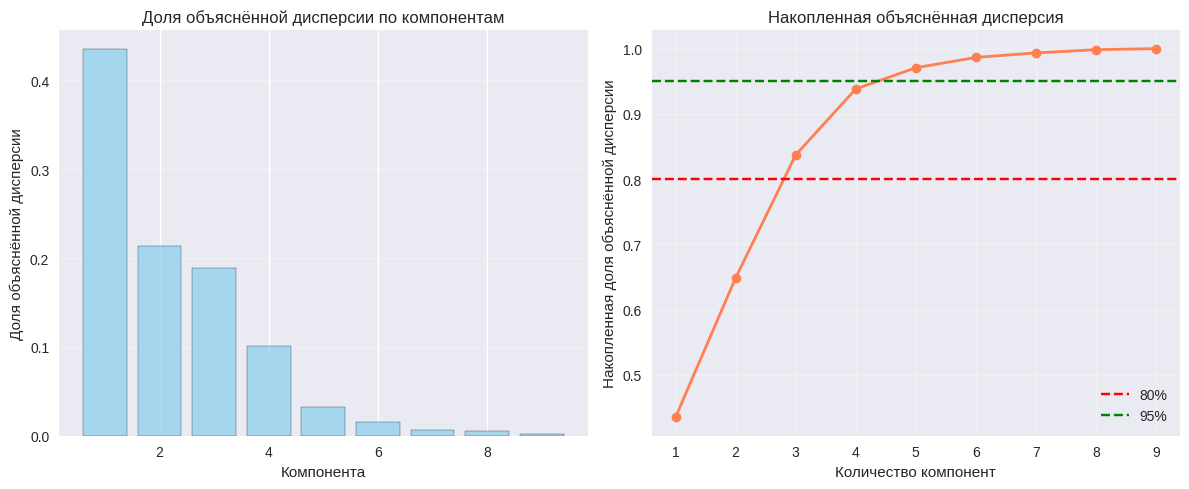


Результаты исследования:
Количество компонент, объясняющих 80% дисперсии: 3
Количество компонент, объясняющих 95% дисперсии: 5

Детализация накопленной дисперсии:
Компоненты 1-1: 0.4348 (43.48%)
Компоненты 1-2: 0.6484 (64.84%)
Компоненты 1-3: 0.8369 (83.69%)
Компоненты 1-4: 0.9381 (93.81%)
Компоненты 1-5: 0.9706 (97.06%)
Компоненты 1-6: 0.9865 (98.65%)
Компоненты 1-7: 0.9934 (99.34%)
Компоненты 1-8: 0.9984 (99.84%)
Компоненты 1-9: 1.0000 (100.00%)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = numeric_df.values
#обрабока пропущенных/бесконечных значений
mask = np.isfinite(X).all(axis=1)
X_clean = X[mask]  # Чистые данные
print(f"Удалено строк с пропущенными/бесконечными значениями: {X.shape[0] - X_clean.shape[0]}")

# Реализация PCA
class PCANumpy:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit_transform(self, X):
        # 1. Стандартизация данных
        X_mean = np.mean(X, axis=0)
        X_std = np.std(X, axis=0)
        # Защита от деления на ноль (если std = 0)
        X_std[X_std == 0] = 1

        X_scaled = (X - X_mean) / X_std

        # 2. Вычисление ковариационной матрицы
        cov_matrix = np.cov(X_scaled, rowvar=False)

        # 3. Нахождение собственных значений и собственных векторов
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # 4. Сортировка компонент по убыванию собственных значений
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.eigenvalues = eigenvalues[sorted_indices]
        self.eigenvectors = eigenvectors[:, sorted_indices]

        # Сохраняем объяснённую дисперсию
        self.explained_variance_ratio = self.eigenvalues / np.sum(self.eigenvalues)

        # Выбираем первые k компонент
        if self.n_components is not None:
            k = self.n_components
            self.components = self.eigenvectors[:, :k]
        else:
            self.components = self.eigenvectors

        # 5. Проекция данных на первые k компонент
        X_projected = X_scaled @ self.components
        return X_projected

# Создаём экземпляр PCA и применяем к данным
pca_numpy = PCANumpy(n_components=None)
X_pca_numpy = pca_numpy.fit_transform(X_clean)  # Используем очищенные данные

# Сравнение с реализацией sklearn
scaler = StandardScaler()
X_scaled_sklearn = scaler.fit_transform(X_clean)

pca_sklearn = PCA(n_components=None)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled_sklearn)

print("Сравнение первых 5 строк проекций:")
print("PCA NumPy:")
print(X_pca_numpy[:5])
print("\nPCA sklearn:")
print(X_pca_sklearn[:5])

# 2.1 Исследование: построение графиков
# Доля объяснённой дисперсии и накопленной объесн дисп
explained_variance = pca_numpy.explained_variance_ratio
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Компонента')
plt.ylabel('Доля объяснённой дисперсии')
plt.title('Доля объяснённой дисперсии по компонентам')
plt.grid(axis='y', alpha=0.3)

# График накопленной объяснённой дисперсии
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='coral', linewidth=2)
plt.axhline(y=0.8, color='red', linestyle='--', label='80%')
plt.axhline(y=0.95, color='green', linestyle='--', label='95%')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная доля объяснённой дисперсии')
plt.title('Накопленная объяснённая дисперсия')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Находим количество компонент для 80% и 95% дисперсии
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("\nРезультаты исследования:")
print(f"Количество компонент, объясняющих 80% дисперсии: {n_components_80}")
print(f"Количество компонент, объясняющих 95% дисперсии: {n_components_95}")

print(f"\nДетализация накопленной дисперсии:")
for i, cum_var in enumerate(cumulative_variance, 1):
    print(f"Компоненты 1-{i}: {cum_var:.4f} ({cum_var*100:.2f}%)")


##**3. Интерпретация главных компонент**

Анализ главных компонент

1. Коэффициенты признаков в первых трёх главных компонентах:
     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
PC1     0.0762   -0.0759             -0.2164       0.4844          0.4895   
PC2    -0.6620    0.6905              0.0009       0.0607          0.0721   
PC3     0.2480   -0.1278             -0.0496      -0.0850          0.0412   

     population  households  median_income  median_house_value  
PC1      0.4701      0.4910         0.0558              0.0452  
PC2      0.0461      0.0718        -0.1783             -0.1922  
PC3      0.0780      0.0265        -0.6711             -0.6735  

2. Признаки с наибольшим вкладом в каждую компоненту:
   PC1: households (коэффициент = 0.4910)
   PC2: latitude (коэффициент = 0.6905)
   PC3: median_house_value (коэффициент = -0.6735)


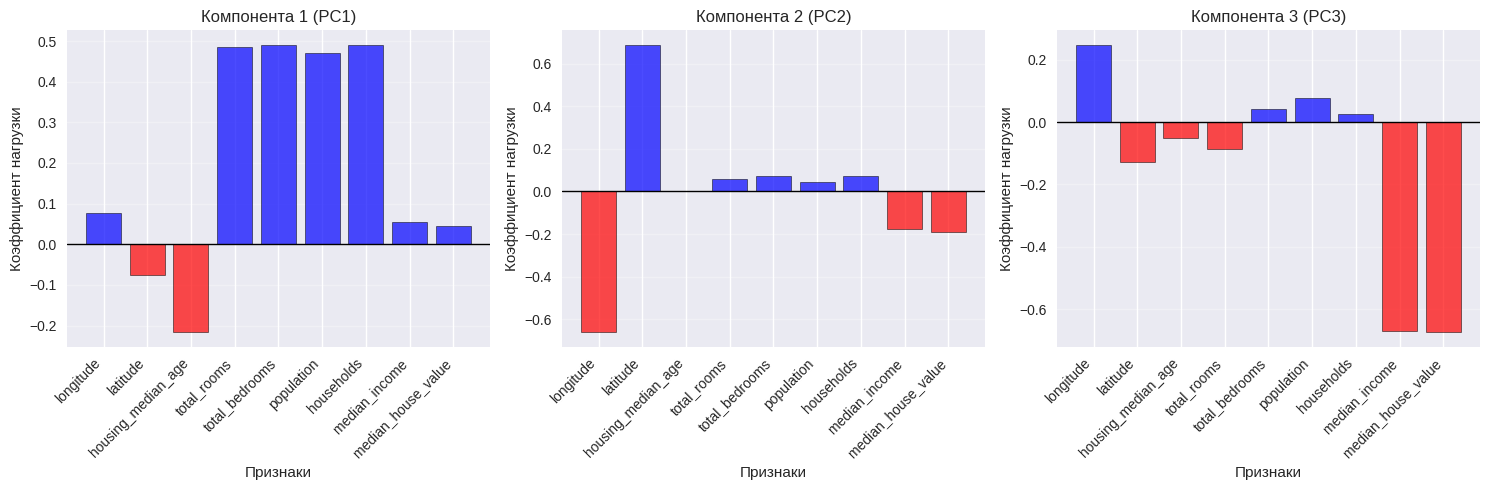


Ответы на вопросы исследования:
1 Какие признаки больше всего влияют на первую компоненту?
   households: 0.4910 (|коэф.| = 0.4910)
   total_bedrooms: 0.4895 (|коэф.| = 0.4895)
   total_rooms: 0.4844 (|коэф.| = 0.4844)

2 Можно ли интерпретировать первую компоненту как комбинацию исходных признаков?
   Да, первая главная компонента (PC1) — это линейная комбинация всех исходных признаков,
   где каждый признак умножается на соответствующий коэффициент (нагрузку).
   Наибольший вклад вносят признаки с наибольшими абсолютными значениями коэффициентов.

   Упрощённая формула PC1 (с учётом топ‑3 признаков):
   PC1 ≈ 0.491×households + 0.490×total_bedrooms + 0.484×total_rooms + ...

3 Есть ли признаки, которые практически не влияют на первые компоненты?
   Нет признаков с пренебрежимо малым влиянием на первые 3 компоненты.
   Все признаки вносят некоторый вклад в первые компоненты.


In [ ]:
print("Анализ главных компонент\n")
# Берём матрицу компонент (собственные векторы), отсортированные по убыванию собственных значений
components = pca_numpy.components[:, :3]  # Первые 3 компоненты
feature_names = numeric_df.columns.tolist()

components_df = pd.DataFrame(
    components.T,  # Транспонируем: строки — компоненты (PC1–PC3), столбцы — признаки
    index=[f'PC{i+1}' for i in range(3)],
    columns=feature_names
)

print("1. Коэффициенты признаков в первых трёх главных компонентах:")
print(components_df.round(4))


print("\n2. Признаки с наибольшим вкладом в каждую компоненту:")
top_features_per_pc = {}
for i in range(3):
    pc_name = f'PC{i+1}'
    # Получаем коэффициенты текущей компоненты
    pc_coefficients = components_df.loc[pc_name]
    # Находим индекс признака с максимальным абсолютным коэффициентом
    max_idx = np.argmax(np.abs(pc_coefficients))
    max_feature = pc_coefficients.index[max_idx]
    max_value = pc_coefficients[max_feature]

    top_features_per_pc[pc_name] = (max_feature, max_value)
    print(f"   {pc_name}: {max_feature} (коэффициент = {max_value:.4f})")


# Визуализация коэффициентов первых 3 компонент - столбчатые диаграммы
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ax in enumerate(axes):
    coefficients = components[:, i]
    # цвета: положительные — синий, отрицательные — красный
    colors = ['blue' if coef >= 0 else 'red' for coef in coefficients]
    bars = ax.bar(feature_names, coefficients, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Компонента {i+1} (PC{i+1})')
    ax.set_xlabel('Признаки')
    ax.set_ylabel('Коэффициент нагрузки')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)  # Линия нуля
    ax.grid(axis='y', alpha=0.3)
    # Поворачиваем подписи по оси X для лучшей читаемости
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("\nОтветы на вопросы исследования:")

pc1_top_features = components_df.loc['PC1'].abs().sort_values(ascending=False).head(3)
print("1 Какие признаки больше всего влияют на первую компоненту?")
for feature, coef_abs in pc1_top_features.items():
    original_coef = components_df.loc['PC1', feature]
    print(f"   {feature}: {original_coef:.4f} (|коэф.| = {coef_abs:.4f})")

print("\n2 Можно ли интерпретировать первую компоненту как комбинацию исходных признаков?")
print("   Да, первая главная компонента (PC1) — это линейная комбинация всех исходных признаков,")
print("   где каждый признак умножается на соответствующий коэффициент (нагрузку).")
print("   Наибольший вклад вносят признаки с наибольшими абсолютными значениями коэффициентов.")
print("\n   Упрощённая формула PC1 (с учётом топ‑3 признаков):")
formula_parts = []
for feature in pc1_top_features.index:
    coef = components_df.loc['PC1', feature]
    formula_parts.append(f"{coef:.3f}×{feature}")
print("   PC1 ≈ " + " + ".join(formula_parts) + " + ...")

print("\n3 Есть ли признаки, которые практически не влияют на первые компоненты?")
threshold = 0.1
small_influence_mask = (
    (np.abs(components[:, 0]) < threshold) &
    (np.abs(components[:, 1]) < threshold) &
    (np.abs(components[:, 2]) < threshold)
)
small_influence_features = [feature_names[i] for i, mask in enumerate(small_influence_mask) if mask]

if small_influence_features:
    print("   Следующие признаки практически не влияют на первые 3 компоненты (|коэф.| < 0.1):")
    for feature in small_influence_features:
        print(f"      {feature}")
else:
    print("   Нет признаков с пренебрежимо малым влиянием на первые 3 компоненты.")
    print("   Все признаки вносят некоторый вклад в первые компоненты.")

##**4. Визуализация данных**

1. Визуализация по исходным признакам: median_income и median_house_value


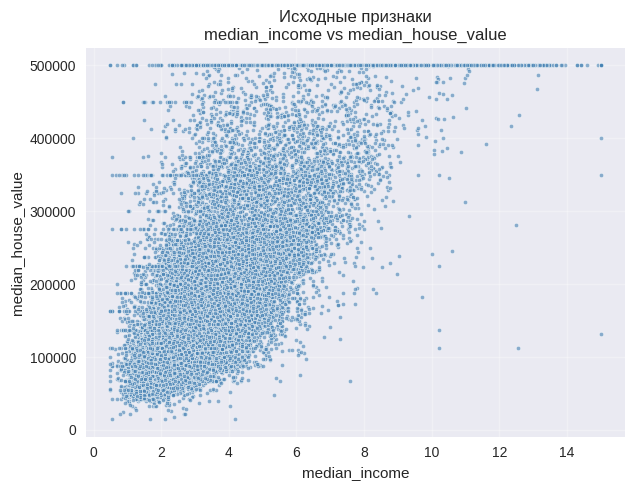


2. Визуализация по двум главным компонентам (PC1 и PC2)


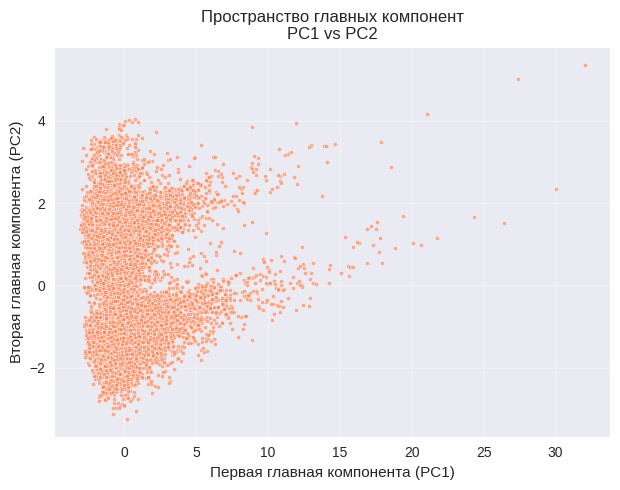


Объясненная дисперсия первых двух компонент:
  PC1: 43.48%
  PC2: 21.36%
  Суммарно: 64.84%


In [ ]:
X_clean_df = pd.DataFrame(X_clean, columns=numeric_df.columns)
feature1 = 'median_income' #средний доход
feature2 = 'median_house_value' #ср стоимость дома

print(f"1. Визуализация по исходным признакам: {feature1} и {feature2}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_clean_df[feature1], X_clean_df[feature2],
            alpha=0.6, s=10, c='steelblue', edgecolors='w',linewidth=0.5)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f'Исходные признаки\n{feature1} vs {feature2}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n2. Визуализация по двум главным компонентам (PC1 и PC2)")
pca_2d = X_pca_numpy[:, :2]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_2d[:, 0], pca_2d[:, 1],
            alpha=0.6, s=10, c='coral', edgecolors='w',linewidth=0.5)
plt.xlabel('Первая главная компонента (PC1)')
plt.ylabel('Вторая главная компонента (PC2)')
plt.title(f'Пространство главных компонент\nPC1 vs PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nОбъясненная дисперсия первых двух компонент:")
print(f"  PC1: {pca_numpy.explained_variance_ratio[0]*100:.2f}%")
print(f"  PC2: {pca_numpy.explained_variance_ratio[1]*100:.2f}%")
print(f"  Суммарно: {(pca_numpy.explained_variance_ratio[0] + pca_numpy.explained_variance_ratio[1])*100:.2f}%")

*1. Визуализация по исходным признакам (median_income и median_house_value)*

Структура распределения:
точки образуют вытянутое облако с явной положительной корреляцией — с ростом дохода увеличивается средняя стоимость жилья.   
Распределение выглядит «размытым»: заметна плотность точек в средней части диапазона доходов (примерно 4–8 единиц), а также «горизонтальные полосы», указывающие на возможные кластеры по стоимости жилья.  
Возможные группы:  
* низкий доходом (слева) и относительно низкая стоимость жилья;
* «основная масса» данных в средней части графика (где концентрация точек максимальна);
* отдельные точки с высоким доходом и очень высокой стоимостью жилья (в верхней правой части).  

Проблемы: из-за масштаба и корреляции между признаками сложно чётко выделить отдельные группы — данные «сгущаются» вдоль основной тенденции.

*2. Визуализация по двум главным компонентам (PC1 vs PC2)*

Структура распределения:
PC1 захватывает наибольшую долю дисперсии (43,48%) и отражает основное направление изменчивости данных.
PC2 объясняет дополнительную дисперсию (21,36%) и выявляет различия.  
Точки образуют плотное скопление в центре с «хвостами» в разные стороны по PC1. По PC2 наблюдается относительно симметричное распределение.  
Возможные группы:
* центральная (основная масса данных), PC1 и PC2 близки к нулю;
* «хвосты» по PC1 указывают на экстремальные значения ;
* по PC2 нет явных кластеров, что говорит о меньшей значимости этой компоненты для разделения данных по исходным признакам.  

### 1. Улучшилась ли визуализация после PCA?  
Да, визуализация улучшилась. Стала более «развёрнутой»; лучше видны крайние значения и структура изменчивости; проще заметить потенциальные выбросы;
снижена корреляция между признаками.

###2. Почему в пространстве главных компонент структура может быть заметнее?  
Структура становится заметнее по следующим причинам:

* PCA поворачивает СК так, чтобы первая компонента (PC1) совпадала с направлением наибольшей дисперсии данных. Это «раскрывает» скрытые закономерности, не видимые в исходных признаках.  
* Вторая компонента (PC2) ортогональна PC1 и показывает следующую по значимости ось изменчивости. Это позволяет увидеть дополнительные различия.  
* Уменьшение размерности (переход от 2 признаков к 2 компонентам) сохраняет основную информацию (64,84% дисперсии), но убирает «шум» и корреляционные искажения.
* Разделение корреляционной зависимости, делая структуру данных более явной.

##**5. Нелинейные методы снижения размерности**

Размер данных для визуализации: 20433 объектов, 9 признаков

 Метод t-SNE
   t-SNE с perplexity = 5
   Завершено за 228.6 секунд
   t-SNE с perplexity = 30
   Завершено за 277.1 секунд
   t-SNE с perplexity = 50
   Завершено за 312.4 секунд

Визуализация результатов t-SNE


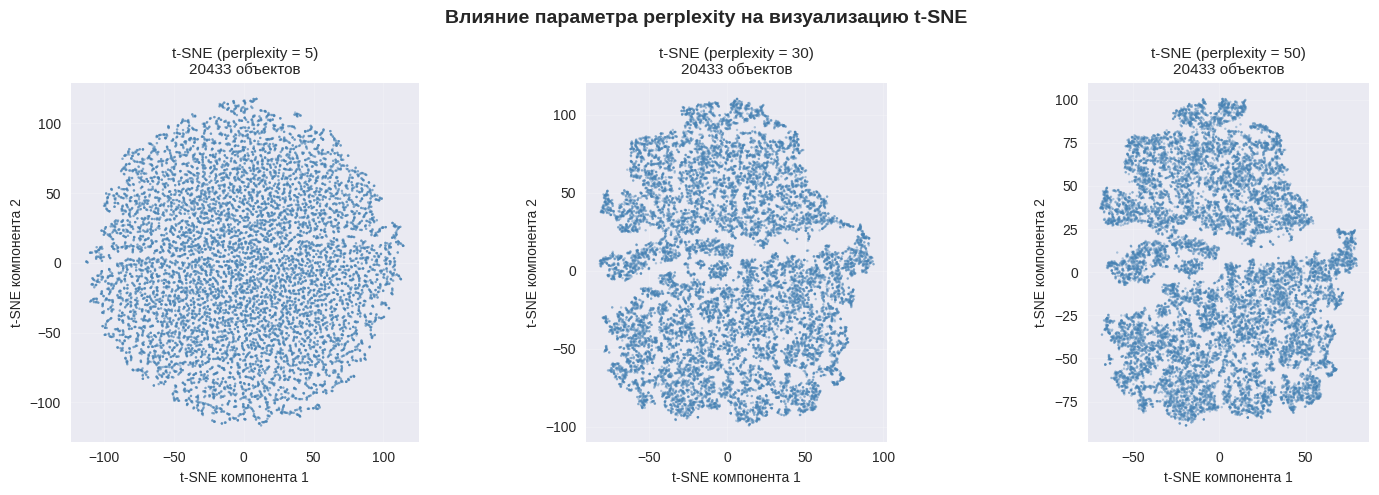

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

print(f"Размер данных для визуализации: {X_scaled_sklearn.shape[0]} объектов, {X_scaled_sklearn.shape[1]} признаков")
print("\n Метод t-SNE")
perplexity_values = [5, 30, 50]
tsne_results = {}

for perplexity in perplexity_values:
    print(f"   t-SNE с perplexity = {perplexity}")
    start_time = time.time()

    # Создаем и обучаем t-SNE на всех данных
    tsne = TSNE(
        n_components=2,           # 2-мерное пространство
        perplexity=perplexity,
        random_state=42,          # случайность для воспроизводимости
        n_iter=1000,              # Кол-во итераций обучения
        learning_rate='auto',     # Автом скорость обучения
        init='pca'                # Инициализация через PCA
    )
    # Преобразуем все данные
    X_tsne = tsne.fit_transform(X_scaled_sklearn)
    tsne_results[perplexity] = X_tsne

    elapsed_time = time.time() - start_time
    print(f"   Завершено за {elapsed_time:.1f} секунд")

print("\nВизуализация результатов t-SNE")
plt.figure(figsize=(15, 5))

for idx, perplexity in enumerate(perplexity_values):
    plt.subplot(1, 3, idx + 1)
    X_tsne = tsne_results[perplexity]
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.4, s=3, c='steelblue', edgecolors='none')
    plt.xlabel('t-SNE компонента 1', fontsize=10)
    plt.ylabel('t-SNE компонента 2', fontsize=10)
    plt.title(f't-SNE (perplexity = {perplexity})\n{len(X_tsne)} объектов', fontsize=11)
    plt.grid(True, alpha=0.2)
    plt.gca().set_aspect('equal')

plt.suptitle('Влияние параметра perplexity на визуализацию t-SNE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Метод UMAP
UMAP найден и будет использован
Работаем на всех 20433 объектах

   Конфигурация 1/5: Локальная структура (5 соседей)
   Параметры: n_neighbors=5, min_dist=0.1
   Завершено за 33.9 секунд
   Конфигурация 2/5: Стандартный (15 соседей)
   Параметры: n_neighbors=15, min_dist=0.1
   Завершено за 42.0 секунд
   Конфигурация 3/5: Глобальная структура (50 соседей)
   Параметры: n_neighbors=50, min_dist=0.1
   Завершено за 71.9 секунд
   Конфигурация 4/5: Очень плотные кластеры
   Параметры: n_neighbors=15, min_dist=0.01
   Завершено за 43.8 секунд
   Конфигурация 5/5: Разреженные кластеры
   Параметры: n_neighbors=15, min_dist=0.5
   Завершено за 42.0 секунд

Визуализация результатов UMAP


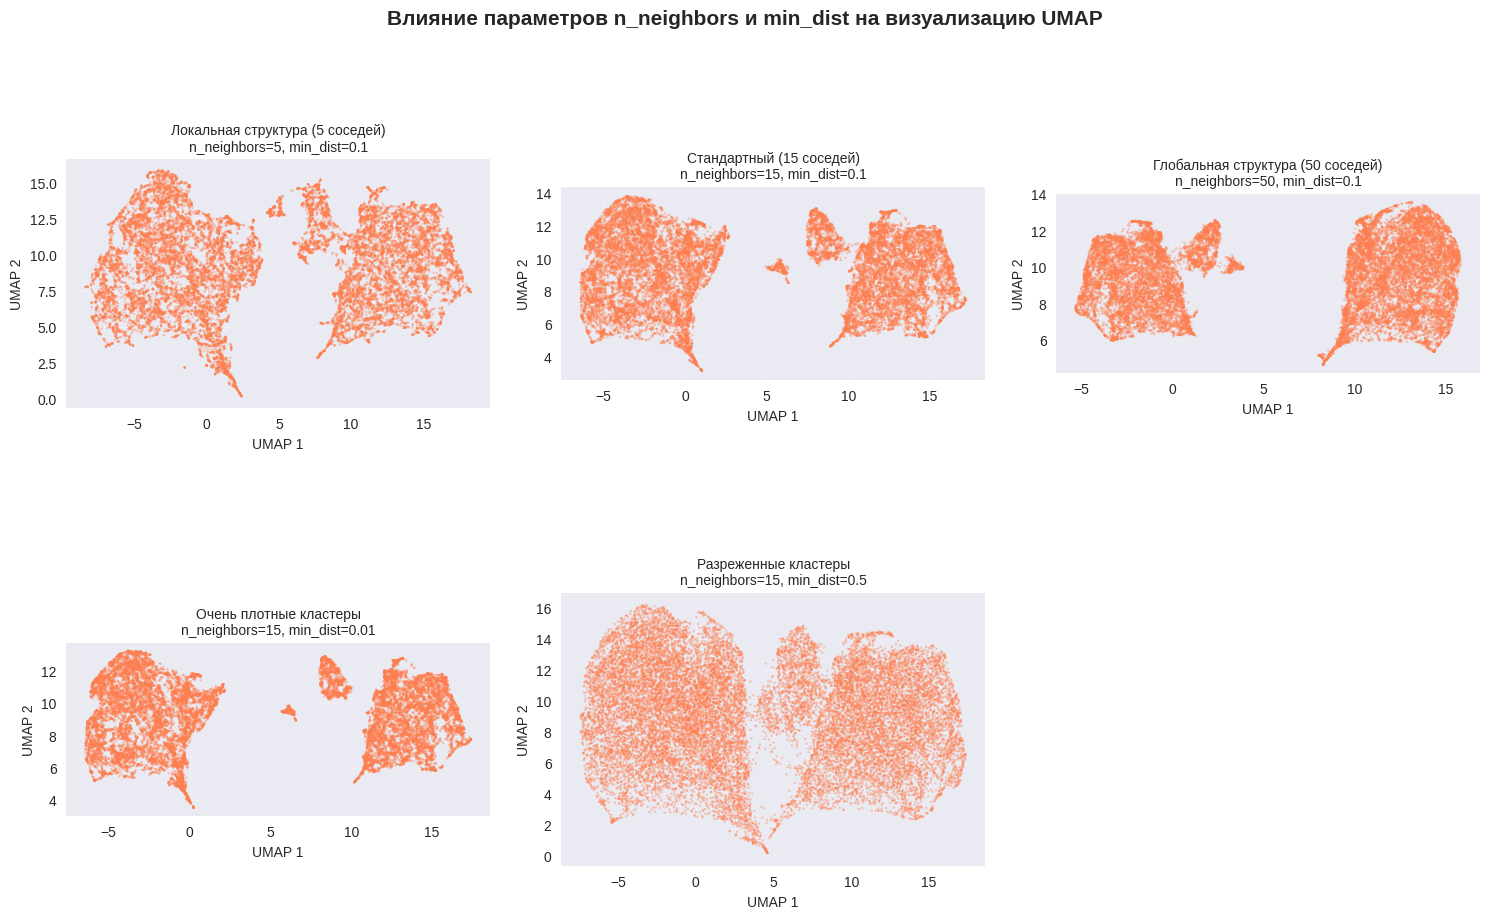

In [ ]:
import time
import warnings
warnings.filterwarnings('ignore')
print("\nМетод UMAP")
# n_neighbors: сколько соседей учитывать
# min_dist: минимальное расстояние между точками в проекции
# Проверяем наличие UMAP
try:
    import umap
    import umap.umap_ as umap
    UMAP_AVAILABLE = True
    print("UMAP найден и будет использован")
    print(f"Работаем на всех {X_scaled_sklearn.shape[0]} объектах\n")

    umap_configs = [
        {'n_neighbors': 5,  'min_dist': 0.1, 'name': 'Локальная структура (5 соседей)'},
        {'n_neighbors': 15, 'min_dist': 0.1, 'name': 'Стандартный (15 соседей)'},
        {'n_neighbors': 50, 'min_dist': 0.1, 'name': 'Глобальная структура (50 соседей)'},
        {'n_neighbors': 15, 'min_dist': 0.01, 'name': 'Очень плотные кластеры'},
        {'n_neighbors': 15, 'min_dist': 0.5, 'name': 'Разреженные кластеры'}
    ]

    umap_results = []

    for i, config in enumerate(umap_configs, 1):
        print(f"   Конфигурация {i}/5: {config['name']}")
        print(f"   Параметры: n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']}")

        start_time = time.time()

        # Создаем UMAP с заданными параметрами
        reducer = umap.UMAP(
            n_components=2,           # Проецируем в 2D
            n_neighbors=config['n_neighbors'],
            min_dist=config['min_dist'],
            random_state=42,          # Фиксируем случайность
            n_epochs=500,             # Количество эпох обучения
            verbose=False
        )

        # Применяем ко всем данным
        X_umap = reducer.fit_transform(X_scaled_sklearn)
        umap_results.append((config, X_umap))

        elapsed_time = time.time() - start_time
        print(f"   Завершено за {elapsed_time:.1f} секунд")

    print("\nВизуализация результатов UMAP")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for idx, (config, X_umap) in enumerate(umap_results):
        axes[idx].scatter(X_umap[:, 0], X_umap[:, 1],alpha=0.4, s=3, c='coral', edgecolors='none')
        axes[idx].set_xlabel('UMAP 1', fontsize=10)
        axes[idx].set_ylabel('UMAP 2', fontsize=10)
        axes[idx].set_title(f'{config["name"]}\nn_neighbors={config["n_neighbors"]}, min_dist={config["min_dist"]}',
                      fontsize=10)
        axes[idx].grid(True, alpha=0.2)
        axes[idx].set_aspect('equal')
    axes[5].set_visible(False)
    plt.suptitle('Влияние параметров n_neighbors и min_dist на визуализацию UMAP', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP не установлен!")

### **1. Как меняется структура данных при разных параметрах?**

Для t-SNE (параметр perplexity):
* При perplexity = 5 структура выглядит «сжатой», кластеры плотно сгруппированы, мелкие детали теряются - метод фокусируется на локальных связях.
* При perplexity = 30 наблюдается баланс между локальными и глобальными структурами: кластеры чётче разделены, видна внутренняя структура групп.
* При perplexity = 50 данные «растягиваются», кластеры становятся более разреженными - метод больше учитывает глобальную структуру, локальные детали менее выражены.

Для UMAP (параметры n_neighbors и min_dist):

* При малом n_neighbors (например, 5) подчёркивается локальная структура - видны мелкие кластеры, но глобальная картина может быть искажена.
* При увеличении n_neighbors (например, до 50) акцент смещается на глобальную структуру - крупные группы лучше различимы, но локальные детали «размываются».
* Малый min_dist (0.01) - очень плотные кластеры, точки «слипаются» — сложно различить внутренние структуры.
* Большой min_dist (0.5) - разреженные кластеры, больше «воздуха» между точками — легче видеть разделение групп, но теряются локальные связи.

### **2. Какой метод даёт наиболее интерпретируемую визуализацию?**
UMAP чаще даёт более интерпретируемую визуализацию по сравнению с t-SNE:
* лучше сохраняет глобальную структуру данных;
* менее склонен к «перепутыванию» далёких точек;
* параметры n_neighbors и min_dist дают больший контроль над балансом «локальное/глобальное».  

t-SNE может создавать визуально привлекательные кластеры, но иногда искажает расстояния между ними, что усложняет интерпретацию.

### **3. Почему результаты разных методов могут существенно отличаться?**
1. Разные цели оптимизации:
* t-SNE сильнее фокусируется на сохранении локальных соседей, иногда в ущерб глобальным отношениям.
* UMAP балансирует между локальными и глобальными структурами, что даёт более стабильные результаты.

2. Чувствительность к параметрам:
* perplexity в t-SNE кардинально меняет масштаб видимости структур.
* В UMAP n_neighbors и min_dist позволяют гибко настраивать детализацию, но по-другому влияют на итоговую проекцию.

3. Стохастичность:
* t-SNE более чувствителен к начальным условиям и может давать разные результаты при одинаковых параметрах.
* UMAP относительно более стабилен.

## **6. Исследование степени сжатия данных**

Исходные данные: 20433 объектов, 9 признаков

Внимание: исходных признаков всего 9, используем k = [2, 5, 9]
Снижение размерности и восстановление данных

    k = 2 
  Размерность после PCA: (20433, 2)
  Размерность после восстановления: (20433, 9)
  Объяснённая дисперсия: 64.84%

    k = 5 
  Размерность после PCA: (20433, 5)
  Размерность после восстановления: (20433, 9)
  Объяснённая дисперсия: 97.06%

    k = 9 
  Размерность после PCA: (20433, 9)
  Размерность после восстановления: (20433, 9)
  Объяснённая дисперсия: 100.00%

Оценка ошибки восстановления

Таблица зависимости ошибки восстановления от числа компонент:
--------------------------------------------------
  Число компонент    | Ошибка восстановления (MSE)
--------------------------------------------------
         2           | 0.351642
         5           | 0.029384
         9           | 0.000000
--------------------------------------------------

Визуальный анализ


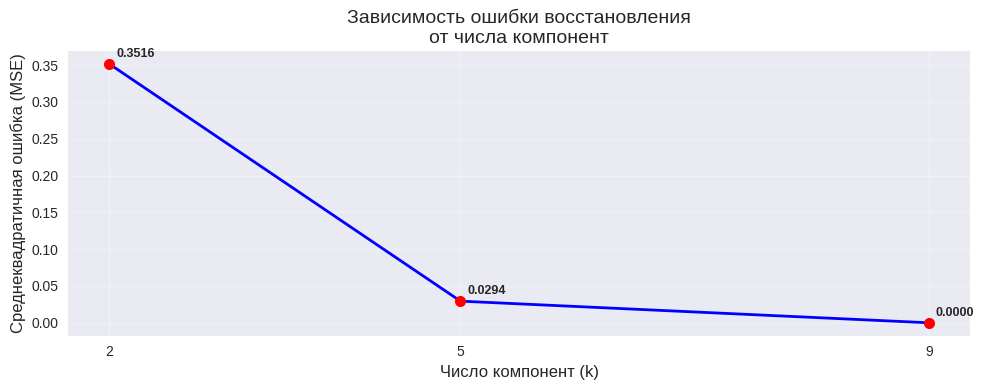


Анализ формы графика:
  Уменьшение ошибки при переходе от k=2 к k=5: 91.6%
  Уменьшение ошибки при переходе от k=5 к k=9: 100.0%
  Ошибка уменьшается равномерно

Анализ точки насыщения:
    Существенного замедления уменьшения ошибки не обнаружено


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

print(f"Исходные данные: {X_clean.shape[0]} объектов, {X_clean.shape[1]} признаков")#данные без пропусков
# Стандартизация данных
scaler_6 = StandardScaler()
X_scaled_6 = scaler_6.fit_transform(X_clean)

# Определяем возможные значения k (число компонент)
n_features_max = X_scaled_6.shape[1]
k_values = [2, 5, 9, 10, 15]

# Корректируем k, если исходных признаков меньше
k_values = [k for k in k_values if k <= n_features_max]
if n_features_max < 15:
    print(f"\nВнимание: исходных признаков всего {n_features_max}, используем k = {k_values}")

# Словари для хранения результатов
mse_results = {}
reconstructed_data = {}
pca_models = {}

print("Снижение размерности и восстановление данных")
for k in k_values:
    print(f"\n    k = {k} ")
    # 1. Обучаем модель PCA
    pca = PCA(n_components=k, random_state=42)
    pca_models[k] = pca

    # 2. Преобразуем данные в пространство из k компонент
    X_reduced = pca.fit_transform(X_scaled_6)
    print(f"  Размерность после PCA: {X_reduced.shape}")

    # 3. Восстанавливаем данные (обратное преобразование)
    X_reconstructed = pca.inverse_transform(X_reduced)
    reconstructed_data[k] = X_reconstructed
    print(f"  Размерность после восстановления: {X_reconstructed.shape}")

    # 4. Сохраняем объяснённую дисперсию
    explained_var = pca.explained_variance_ratio_
    cumsum_var = np.sum(explained_var)
    print(f"  Объяснённая дисперсия: {cumsum_var*100:.2f}%")

print("\nОценка ошибки восстановления")
print("\nТаблица зависимости ошибки восстановления от числа компонент:")
print("-" * 50)
print(f"{'Число компонент':^20} | {'Ошибка восстановления (MSE)':^25}")
print("-" * 50)

for k in k_values:
    # Вычисляем MSE между исходными и восстановленными данными
    mse = mean_squared_error(X_scaled_6, reconstructed_data[k])
    mse_results[k] = mse
    print(f"{k:^20} | {mse:.6f}")
print("-" * 50)

print("\nВизуальный анализ")
# Визуальный анализ: зависимость ошибки восстановления от числа компонент
plt.figure(figsize=(10, 4))

plt.plot(k_values, list(mse_results.values()), 'bo-', linewidth=2,
         markersize=8, markerfacecolor='red', markeredgecolor='black')
plt.xlabel('Число компонент (k)', fontsize=12)
plt.ylabel('Среднеквадратичная ошибка (MSE)', fontsize=12)
plt.title('Зависимость ошибки восстановления\nот числа компонент', fontsize=14)
# Сетка и разметка делений на оси X
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Добавляем значения MSE на график
for k in k_values:
    plt.annotate(f'{mse_results[k]:.4f}',
                xy=(k, mse_results[k]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# Оптимальное размещение элементов и отображение графика
plt.tight_layout()
plt.show()

print("\nАнализ формы графика:")
# Вычисляем скорость уменьшения ошибки
mse_list = list(mse_results.values())
if len(mse_list) >= 2:
    first_reduction = (mse_list[0] - mse_list[1]) / mse_list[0] * 100
    last_reduction = (mse_list[-2] - mse_list[-1]) / mse_list[-2] * 100 if len(mse_list) > 2 else 0

    print(f"  Уменьшение ошибки при переходе от k={k_values[0]} к k={k_values[1]}: {first_reduction:.1f}%")
    if len(mse_list) > 2:
        print(f"  Уменьшение ошибки при переходе от k={k_values[-2]} к k={k_values[-1]}: {last_reduction:.1f}%")

    if first_reduction > last_reduction:
        print("  Ошибка быстро уменьшается при малых k, затем замедляется")
    else:
        print("  Ошибка уменьшается равномерно")

# Определяем точку "излома" (где уменьшение становится незначительным)
print("\nАнализ точки насыщения:")
for i in range(1, len(k_values)):
    reduction = (mse_results[k_values[i-1]] - mse_results[k_values[i]]) / mse_results[k_values[i-1]] * 100
    if reduction < 10:
        print(f"    После k={k_values[i-1]} уменьшение ошибки становится незначительным (<10%)")
        break
else:
    print("    Существенного замедления уменьшения ошибки не обнаружено")

### **1. Почему при малом числе компонент ошибка восстановления большая?**
При малом k=2 теряется много информации — PCA отбрасывает компоненты с наименьшей дисперсией, которые всё же несут часть данных. Поэтому восстановленные данные сильно отличаются от исходных (MSE = 0.351642, объяснённая дисперсия лишь 64.84%).

### **2. Почему увеличение числа компонент уменьшает ошибку?**
Каждая дополнительная компонента сохраняет часть дисперсии (информации) исходных данных. Чем больше компонент, тем точнее можно восстановить исходное положение точек в пространстве, уменьшая ошибку реконструкции.

### **3. Можно ли полностью восстановить исходные данные при использовании всех компонент?**
Да, при k, равном числу исходных признаков, PCA сохраняет 100% дисперсии — данные восстанавливаются без потерь (MSE = 0). Особенность метода: все исходные данные сохраняются в главных компонентах.

### **4. Как это связано с объяснённой дисперсией PCA?**
Объяснённая дисперсия - доля вариативности данных, сохранённая после снижения размерности. Чем больше k, тем выше объяснённая дисперсия и тем точнее восстановление:
k=2 - 64.84% - большая ошибка;
k=5 - 97.06% - существенное снижение ошибки;
k=9 - 100% - нулевая ошибка.

### **5. Как можно определить разумное число компонент, при котором данные уже хорошо описаны, но размерность существенно меньше?**
Использовать критерий «точки насыщения» — момента, когда дальнейшее увеличение k даёт незначительное снижение ошибки.   

В нашем случае:  
переход с k=2 на k=5 даёт резкое уменьшение ошибки (на 91.6%);
переход с k=5 на k=9 практически полностью устраняет ошибку (100%).

Вывод: k=5 — разумный компромисс:
* размерность в 2 раза меньше исходной (5 из 9 признаков);
* сохранено 97.06% дисперсии;
* ошибка восстановления уже низкая (0.029384).   

Это баланс между сжатием данных и потерей информации.

## **7. Итоговый анализ**

### **1. Какую роль играет снижение размерности в анализе данных?**
* уменьшает «шум» и корреляционные искажения;
* сокращает количество признаков при сохранении ключевой информации (задание2:3 компоненты объясняют 80% дисперсии);
* упрощает визуализацию (переход от 9 признаков к 2–3);
* ускоряет обучение моделей за счёт меньшего объёма данных;
* помогает выявить скрытые структуры и кластеры (задания 4, 5).

### **2. Всегда ли уменьшение размерности полезно?**

Нет, не всегда:
* если данные не имеют избыточности (низкая корреляция признаков), сжатие может привести к потере важной информации;
* при чрезмерном сокращении компонентов теряется слишком много деталей(например, k=2 в задании 6 с MSE=0.351642);
* для задач, где критична точность, сильное сжатие может быть неприемлемо;
* если структура данных нелинейна, линейные методы (PCA) могут работать хуже, чем нелинейные (t-SNE, UMAP).

### **3. В каких случаях линейные методы могут работать хуже нелинейных?**

Линейные методы (PCA):
* плохо справляются с нелинейными зависимостями между признаками;
* не выявляют сложные кластерные структуры;
* искажают расстояния между точками в нелинейных данных.

Нелинейные методы (t-SNE, UMAP) лучше подходят, когда:
* данные имеют сложную топологию;
* нужно сохранить локальные соседства точек;
* важна визуализация кластеров с нелинейными границами;
* данные содержат «свёрнутые» структуры, которые PCA «разворачивает» некорректно.

### **4. Преимущества и ограничения методов PCA, t-SNE и UMAP**

`PCA`:  
*Преимущества:*
быстрый и стабильный расчёт;  
сохраняет глобальную структуру данных;  
даёт интерпретируемые компоненты;  
легко оценить потерю информации через объяснённую дисперсию.

*Ограничения:*  
линейность — не видит нелинейных паттернов;  
может терять детали при сильном сжатии;  
чувствителен к масштабу признаков и выбросам.

`t-SNE`:  
*Преимущества:*  
отлично выявляет локальные кластеры;  
хорошо работает с высокоразмерными данными для визуализации;  
параметр perplexity позволяет настраивать баланс локального/глобального.

*Ограничения:*  
не подходит для восстановления исходных данных;   
чувствителен к параметрам и начальным условиям;  
высокая вычислительная сложность;  
искажает глобальные расстояния.

`UMAP`:

*Преимущества:*  
сохраняет и локальные, и глобальные структуры;
быстрее t-SNE;  
параметры n_neighbors и min_dist дают гибкий контроль над визуализацией;  
подходит для больших наборов данных.

*Ограничения:*  
менее интерпретируем, чем PCA;  
может требовать тонкой настройки параметров;  
не предназначен для прямого восстановления данных.
